# FPUT Problem: ML Model Evaluation

## Overview

This notebook evaluates neural network (NN) flow maps for the Fermi-Pasta-Ulam-Tsingou (FPUT) problem.

In particular, this notebook will:
1. Load trained NN flow maps from specified checkpoint files.
2. Benchmark the NN forward pass runtime.
3. Generate and compare trajectories using the NN flow maps versus reference solutions, supporting both one-step and recursive prediction modes.

## Mathematical Model
Consider a chain of $2m$ mass points connected by alternating soft nonlinear springs and stiff linear springs. Let the displacements from equilibrium be given by $q_1, \ldots, q_{2m}$, with $q_0 = q_{2m+1} = 0$, and let the corresponding momenta be $p_i = d q_i/dt$. The Hamiltonian of this system is given by
\begin{align*}
    H(p,q) = \frac{1}{2} \sum_{i=1}^{m} (p_{2i-1}^2 + p_{2i}^{2}) + \frac{\omega^2}{4} \sum_{i=1}^{m} (q_{2i}-q_{2i-1})^2 +\sum_{i=0}^{m} (q_{2i+1}-q_{2i})^4,
\end{align*}
where $\omega \gg 1$ represents the high frequency of the stiff linear springs. 

To capture the multiscale behavior inherent in the FPUT system, we perform a change of variables that decouples the slow and fast components. For $i=1,\ldots,m$, define 
slow variables 
\begin{align*}
    x_{0,i} := \frac{1}{\sqrt{2}} (q_{2i} + q_{2i-1}), \quad y_{0,i} := \frac{1}{\sqrt{2}} (p_{2i} + p_{2i-1}),
\end{align*}
and fast variables
\begin{align*}
    x_{1,i} := \frac{1}{\sqrt{2}} (q_{2i} - q_{2i-1}), \quad y_{1,i} := \frac{1}{\sqrt{2}} (p_{2i} - p_{2i-1}).
\end{align*}

Physically, $x_{0,i}$ represents a scaled displacement of the i-th stiff spring, while $x_{1,i}$ characterizes its expansion or compression. Their corresponding momenta are $y_{0,i}$ and $y_{1,i}$. 

Rewriting the Hamiltonian in these new variables, we obtain 
\begin{align*}
    H(y,x) = &\frac{1}{2} \sum_{i=1}^{m} (y_{0,i}^2 + y_{1,i}^2) + \frac{\omega^2}{2} \sum_{i=1}^{m} x_{1,i}^2 \nonumber \\
    &+ \frac{1}{4}\left( (x_{0,1}-x_{1,1})^4 + \sum_{i=1}^{m-1} (x_{0,i+1}-x_{1,i+1}-x_{0,i}-x_{1,i})^4 + (x_{0,m}+x_{1,m})^4 \right).
\end{align*}
The kinetic energies corresponding to the slow and fast components are given by 
\begin{align*}
    T_0 = \frac{1}{2} \|y_0\|^2, \quad T_1 = \frac{1}{2} \|y_1\|^2.
\end{align*}

In addition to the conservation of the total energy, this system has an almost-invariant behavior in the stiff spring energies. Defining the energy of the $j$th stiff spring as
\begin{align*}
    I_j(y_{1,j},x_{1,j}) = \frac{1}{2}(y_{1,j}^2 + \omega^2 x_{1,j}^2),
\end{align*}
one finds that the total oscillatory energy 
\begin{align*}
    I=\sum_{j=1}^m{I_j}
\end{align*}
remains nearly constant (via the modulated Fourier expansion technique), satisfying
\begin{align*}
    I(y(t),x(t)) = I(y(0),x(0)) + \mathcal{O}(\omega^{-1}).
\end{align*}

## Setup and Dependencies

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
import time
import torch

from notebook_utils.dataprocessing import FPU, FPUTrajectory, FPUDataset
from notebook_utils.visualization import FPUVisualizer
from notebook_utils.evaluation import (
    find_latest_ckpt, load_model_from_ckpt, time_forward,
    one_step_predict, recursive_predict, 
)

Trajectory = FPUTrajectory
Dataset = FPUDataset

viz = FPUVisualizer()

## Load Models

In [4]:
ALL_MODELS = {
    ### HMC-H0 (version1) collocation, fixed omega model, EBE
    "Taylor0IdEnf: VV uniform(0,0.125) h=0.001, branch": {
        "model_name": "TaylorBasedIdentityEnforcedSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250326-225912_56qkh3/checkpoints",
    },
    "Taylor1IdEnf: VV uniform(0,0.125) h=0.001, branch": {
        "model_name": "TaylorBasedIdentityEnforcedSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250326-225428_05vz85/checkpoints",
    },
    "S0F0TaylorIdEnf: VV uniform(0,0.125) h=0.001": {
        "model_name": "SFTaylorBasedIdentityEnforcedSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250327-030330_axt6sa/checkpoints",
    },
    "S2F0TaylorIdEnf: VV uniform(0,0.125) h=0.001": {
        "model_name": "SFTaylorBasedIdentityEnforcedSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250327-025806_cwwx7j/checkpoints",
    },
    "S2F0TaylorIdEnf: VV uniform(0,0.125) h=0.001, MSE": {
        "model_name": "SFTaylorBasedIdentityEnforcedSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250327-033130_sariwp/checkpoints",
    },
    ### HMC-H0 (version1) collocation, fixed omega model, EBE, trained for 1M steps
    "S0F0TaylorIdEnf: VV uniform(0,0.125) h=0.001": {
        "model_name": "SFTaylorBasedIdentityEnforcedSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250327-214141_sqgu22/checkpoints",
    },
    "S2F0TaylorIdEnf: VV uniform(0,0.125) h=0.001": {
        "model_name": "SFTaylorBasedIdentityEnforcedSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250327-213616_qokg3y/checkpoints",
    },
    "S2F0TaylorIdEnf: VV uniform(0,0.25) h=0.001": {
        "model_name": "SFTaylorBasedIdentityEnforcedSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250329-144724_pawwye/checkpoints",
    },
    "S2F0TaylorIdEnf: VV uniform(0,0.5) h=0.001": {
        "model_name": "SFTaylorBasedIdentityEnforcedSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250330-133133_tslwys/checkpoints",
    },
    "S2F0TaylorIdEnf: VV uniform(0,1) h=0.001": {
        "model_name": "SFTaylorBasedIdentityEnforcedSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250331-001958_wej3v2/checkpoints",
    },
    "S2F0TaylorIdEnf: VV uniform(0,0.5) h=0.001, trained for 5M steps": {
        "model_name": "SFTaylorBasedIdentityEnforcedSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250401-154635_cyrxxi/checkpoints",
    },
    "S2F0TaylorIdEnf: VV uniform(0,1) h=0.001, trained for 5M steps": {
        "model_name": "SFTaylorBasedIdentityEnforcedSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250401-015245_854ufq/checkpoints",
    },
    "S2F0TaylorIdEnf: VV uniform(0,0.125) h=0.001, trained for 5M steps": {
        "model_name": "SFTaylorBasedIdentityEnforcedSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250409-011834_w3dj66/checkpoints",
    },
    ## HMC-H0 (version1) collocation, fixed omega model, EBE, uniform grid time collocation
    "S2F0TaylorIdEnf: VV uniform_grid(0,0.125) h=0.001": {
        "model_name": "SFTaylorBasedIdentityEnforcedSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250404-233044_wb7s7r/checkpoints",
    },
    "S2F0TaylorIdEnf: VV uniform_grid(0,T) dynamic h=0.001": {
        "model_name": "SFTaylorBasedIdentityEnforcedSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250405-024810_csz9wr/checkpoints",
    },
    ## HMC-H0 (version 1) data 
    "T0Centered: data at 1, EBE, S=1, use f(u)": {
        "model_name": "SFTaylorBasedT0CenteredSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250401-224437_7f4kbk/checkpoints",
    },
    "T0Centered: data at 1, MSE, S=1": {
        "model_name": "SFTaylorBasedT0CenteredSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250404-014144_rp3fx2/checkpoints",
    },
    "T0Centered: data at 1, EBE, S=1": {
        "model_name": "SFTaylorBasedT0CenteredSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250403-193303_03bj45/checkpoints",
    },
    "T0Centered: data at 1, EBE, S=3": {
        "model_name": "SFTaylorBasedT0CenteredSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250404-020740_pm1udj/checkpoints",
    },
    ### omega = 300
    ### HMC-H0 (version 4) data 
    "[omega=300] T0Centered: data at 1, EBE, S=1": {
        "model_name": "SFTaylorBasedT0CenteredSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250405-161021_voacu1/checkpoints",
    },
    "[omega=300] T0Centered: data at 1, EBE, S=3": {
        "model_name": "SFTaylorBasedT0CenteredSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250405-224742_ps17q2/checkpoints",
    },
    "[omega=300] T0Centered: data at 1, EBE, S=5": {
        "model_name": "SFTaylorBasedT0CenteredSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250406-182238_8x29ca/checkpoints",
    },
}

# Select models to evaluate
# SELECTED_MODELS = [
#     "[omega=300] T0Centered: data at 1, EBE, S=1",
#     "[omega=300] T0Centered: data at 1, EBE, S=3", 
#     "[omega=300] T0Centered: data at 1, EBE, S=5",
# ]  # Experiment with different data sequence lengths 

# SELECTED_MODELS = [
#     "S0F0TaylorIdEnf: VV uniform(0,0.125) h=0.001",
#     "S2F0TaylorIdEnf: VV uniform(0,0.125) h=0.001",
# ]  # Experiment with different Taylor series orders

# SELECTED_MODELS = [
#     "S2F0TaylorIdEnf: VV uniform(0,0.125) h=0.001",
#     "S2F0TaylorIdEnf: VV uniform(0,0.25) h=0.001",
#     "S2F0TaylorIdEnf: VV uniform(0,0.5) h=0.001, trained for 5M steps",
#     "S2F0TaylorIdEnf: VV uniform(0,1) h=0.001, trained for 5M steps",
# ]  # Experiment with different time intervals

# SELECTED_MODELS = [
#     "T0Centered: data at 1, MSE, S=1",
#     "T0Centered: data at 1, EBE, S=1",
# ]  # Experiment with different loss functions

SELECTED_MODELS = [
    "S2F0TaylorIdEnf: VV uniform(0,0.125) h=0.001, MSE",
    "S2F0TaylorIdEnf: VV uniform(0,0.125) h=0.001"
]  # Experiment with different loss functions

# SELECTED_MODELS = [
#     "S2F0TaylorIdEnf: VV uniform(0,0.125) h=0.001",
#     "T0Centered: data at 1, EBE, S=1",
# ]  # Best models for omega=50

# SELECTED_MODELS = [
#     "[omega=300] T0Centered: data at 1, EBE, S=5",
# ]  # Best models for omega=300

models = []
model_labels = []
for key in SELECTED_MODELS:
    ckpt_info = ALL_MODELS[key]
    ckpt_path = find_latest_ckpt(ckpt_info["ckpt_dir"])
    model, _ = load_model_from_ckpt(ckpt_path, ckpt_info["model_name"])
    print(model)
    model.to(torch.float64)
    print(f"Model dtype: {model.dtype}")
    models.append(model)
    model_labels.append(key)

SFTaylorBasedIdentityEnforcedSolutionMap(
  problem: FPU(omega=50)
  use_dimensionless: True
  problem_param_keys: []
  order_slow: 2
  order_fast: 0
  (loss_fn): MSELoss()
  (net_slow): PirateNet(
    (encoder1): Linear(in_features=25, out_features=800, bias=True)
    (encoder2): Linear(in_features=25, out_features=800, bias=True)
    (input_layer): Linear(in_features=25, out_features=800, bias=True)
    (output_layer): Linear(in_features=800, out_features=6, bias=False)
    (res_blocks): ModuleList(
      (0-1): 2 x PirateNetBlock(
        (linears): ModuleList(
          (0-2): 3 x Linear(in_features=800, out_features=800, bias=True)
        )
        (activation): ELU(alpha=1.0)
      )
    )
    (activation): ELU(alpha=1.0)
  )
  (net_fast): PirateNet(
    (encoder1): Linear(in_features=25, out_features=800, bias=True)
    (encoder2): Linear(in_features=25, out_features=800, bias=True)
    (input_layer): Linear(in_features=25, out_features=800, bias=True)
    (output_layer): Linea

## Analysis

### 1. Runtime

Measure forward pass runtime

In [6]:
for model, label in zip(models, model_labels):
    compare = time_forward(model, nsteps_list=[0, 1])
    print(f"Model: {label}")
    print(compare)

Model: S0F0TaylorIdEnf: VV uniform(0,0.125) h=0.001
[--------------------------------------- forward time --------------------------------------]
                                                           |  cpu: nsteps=0  |  cpu: nsteps=1
1 threads: ----------------------------------------------------------------------------------
      u: torch.Size([1, 12]), t: torch.Size([1, 1])        |      177.4      |     3235750.0 
      u: torch.Size([64, 12]), t: torch.Size([64, 1])      |      176.5      |    14062000.0 
      u: torch.Size([128, 12]), t: torch.Size([128, 1])    |      175.2      |    25886875.0 
      u: torch.Size([512, 12]), t: torch.Size([512, 1])    |      176.3      |    92675333.0 
      u: torch.Size([1024, 12]), t: torch.Size([1024, 1])  |      175.6      |   176465104.0 
      u: torch.Size([2048, 12]), t: torch.Size([2048, 1])  |      175.7      |   353231916.0 

Times are in nanoseconds (ns).

Model: S2F0TaylorIdEnf: VV uniform(0,0.125) h=0.001
[----------------

### 2. 1-Step Predictions

Evaluate the model at different times

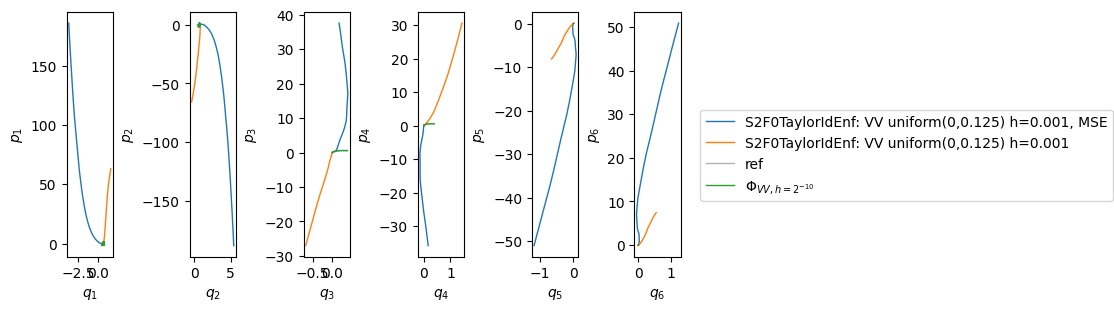

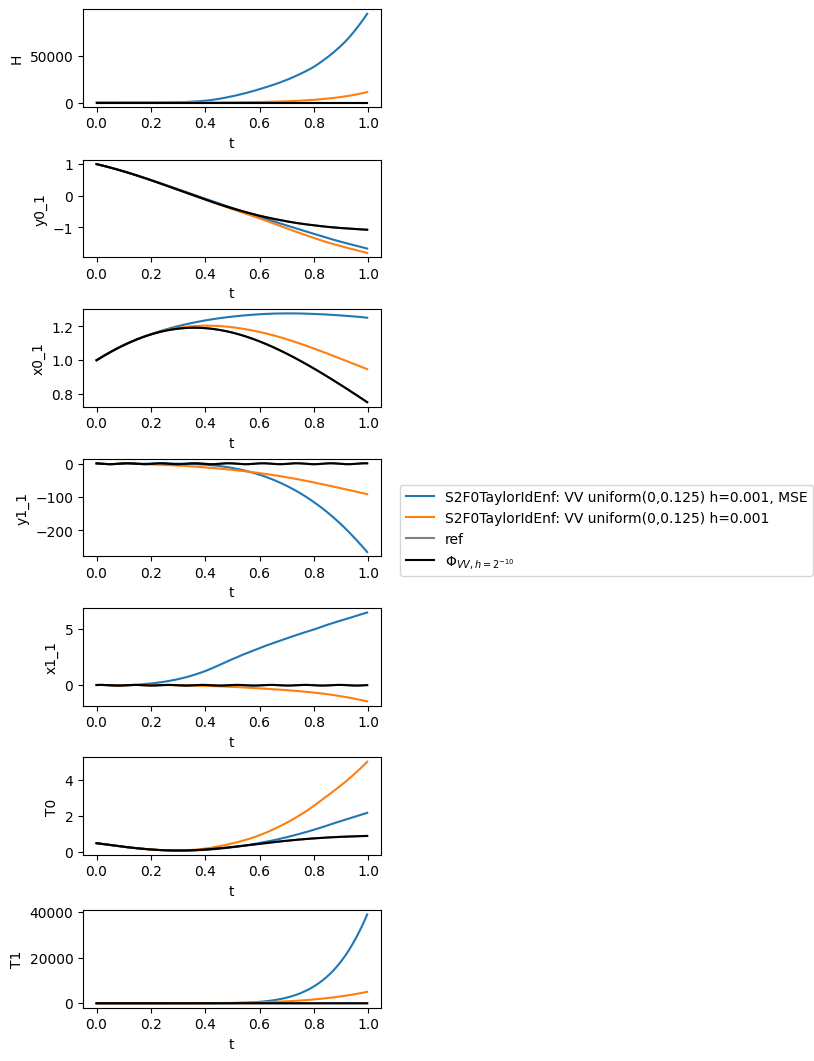

After alignment: 
	traj = FPUTrajectory(t_range=[0.0, 0.99609375], dt=0.00390625, u0=[0.         1.41421356 0.         0.         0.         0.
 0.69296465 0.72124892 0.         0.         0.         0.        ], states=States(problem=FPU(omega=50.0), shape=(256, 12)))
	ref_traj = FPUTrajectory(t_range=[0.0, 0.99609375], dt=0.00390625, u0=[0.         1.41421356 0.         0.         0.         0.
 0.69296465 0.72124892 0.         0.         0.         0.        ], states=States(problem=FPU(omega=50.0), shape=(256, 12)))
S2F0TaylorIdEnf: VV uniform(0,0.125) h=0.001, MSE n=1 abs_traj_err = 0.0034590733081893968
S2F0TaylorIdEnf: VV uniform(0,0.125) h=0.001, MSE n=255 abs_traj_err = 280.5433059958627
S2F0TaylorIdEnf: VV uniform(0,0.125) h=0.001, MSE n=1 abs_H_err = 0.03454866402492973
S2F0TaylorIdEnf: VV uniform(0,0.125) h=0.001, MSE n=255 abs_H_err = 95130.41506399178
S2F0TaylorIdEnf: VV uniform(0,0.125) h=0.001, MSE n=1 abs_traj_err_y0 = 3.315421890015581e-06
S2F0TaylorIdEnf: VV uniform(

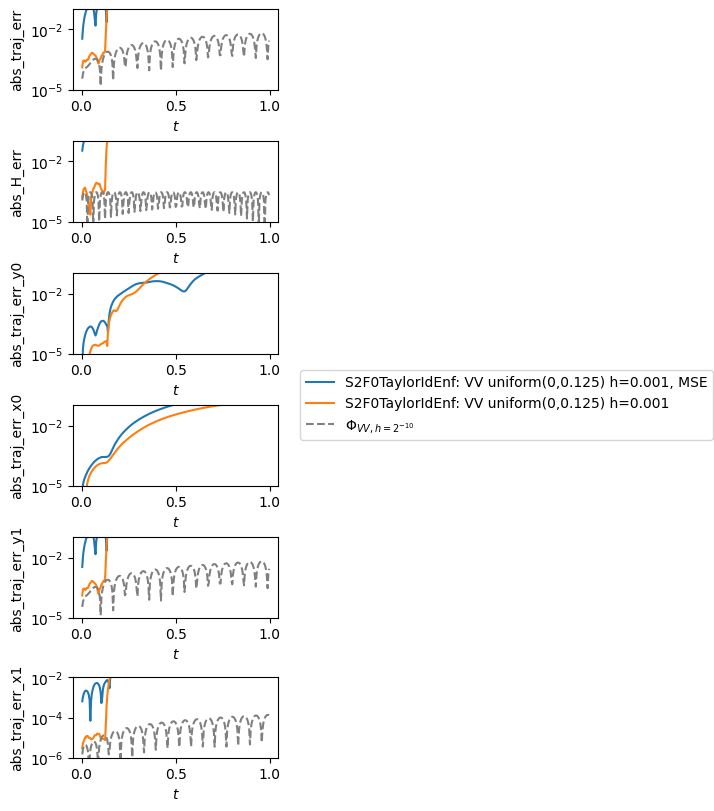

After alignment: 
	traj = FPUTrajectory(t_range=[0.0, 0.99609375], dt=0.00390625, u0=[0.         1.41421356 0.         0.         0.         0.
 0.69296465 0.72124892 0.         0.         0.         0.        ], states=States(problem=FPU(omega=50.0), shape=(256, 12)))
	ref_traj = FPUTrajectory(t_range=[0.0, 0.99609375], dt=0.00390625, u0=[0.         1.41421356 0.         0.         0.         0.
 0.69296465 0.72124892 0.         0.         0.         0.        ], states=States(problem=FPU(omega=50.0), shape=(256, 12)))
S2F0TaylorIdEnf: VV uniform(0,0.125) h=0.001, MSE n=1 abs_traj_err = 0.003424813576501122
S2F0TaylorIdEnf: VV uniform(0,0.125) h=0.001, MSE n=255 abs_traj_err = 280.5406351863923
S2F0TaylorIdEnf: VV uniform(0,0.125) h=0.001, MSE n=1 abs_H_err = 0.034662724340556395
S2F0TaylorIdEnf: VV uniform(0,0.125) h=0.001, MSE n=255 abs_H_err = 95130.41527585861
S2F0TaylorIdEnf: VV uniform(0,0.125) h=0.001, MSE n=1 abs_traj_err_y0 = 3.2742781267184243e-06
S2F0TaylorIdEnf: VV uniform

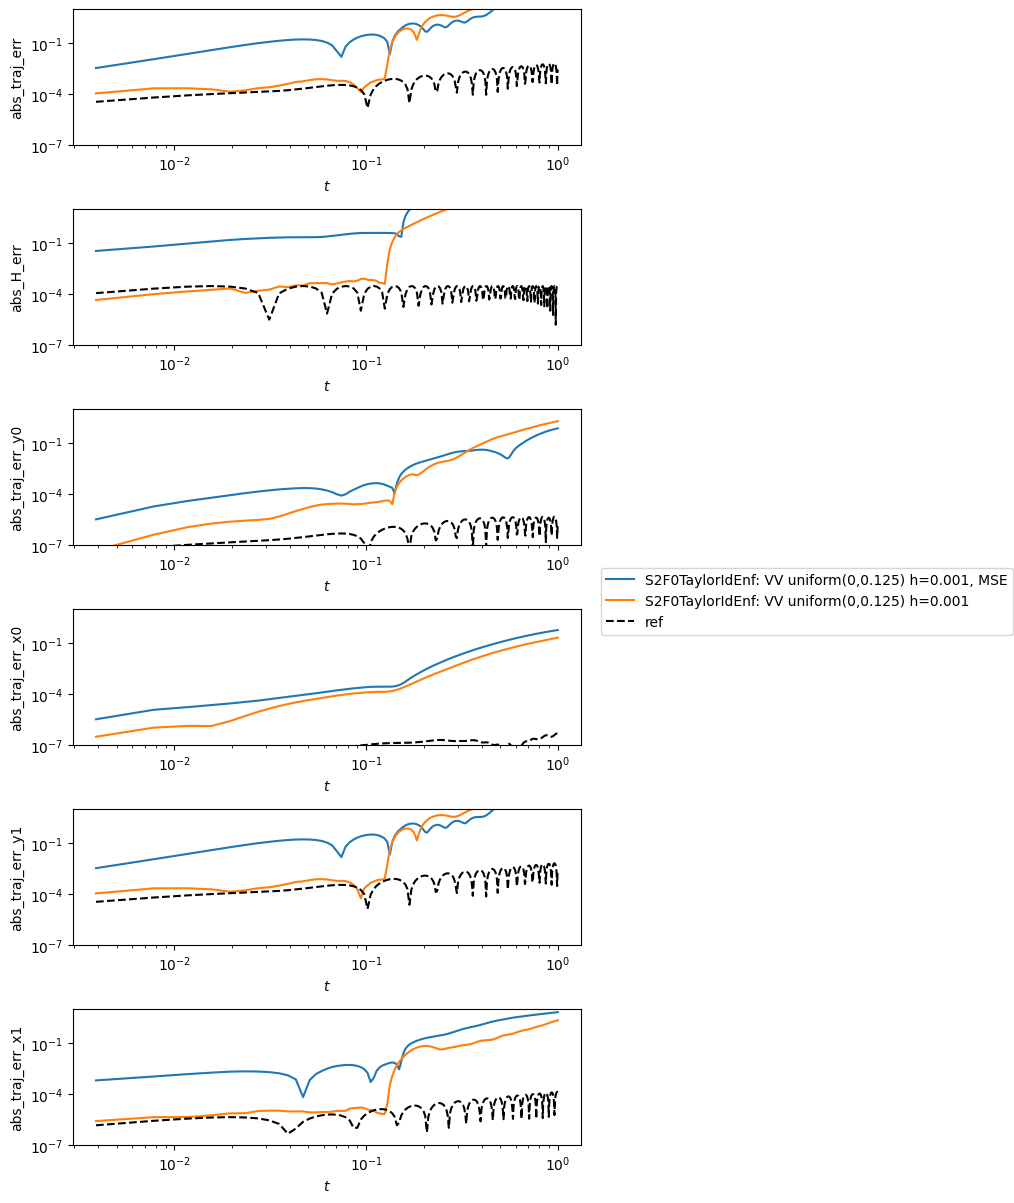

In [5]:
def trajectory_from_taylor_expansion(u0, times, p, order):
    """Generate trajectory using Taylor series expansion."""
    processor = FPU(**p)
    u = processor.compute_taylor_series(u0, times, order)
    return Trajectory.from_vx(times, u, **p)

def build_trajectory_list(pred_trajs, model_labels, ref_traj, coarse_ref_traj, taylor_trajs, 
                         show_coarse_ref, show_taylor, t_list):
    """Build lists of trajectories, labels, and colors for plotting."""
    trajs = pred_trajs.copy()
    labels = model_labels.copy()
    colors = [f"C{i}" for i in range(len(model_labels))]
    
    # Add reference
    if ref_traj:
        trajs.append(ref_traj.select_between(t_list.min(), t_list.max()))
        labels.append("ref")
        colors.append("black")
    
    # Add coarse reference if requested
    if show_coarse_ref and coarse_ref_traj:
        trajs.append(coarse_ref_traj.select_between(t_list.min(), t_list.max()))
        labels.append(r"$\Phi_{VV,h=2^{-10}}$")
        colors.append("grey")
    
    # Add Taylor trajectories if requested
    if show_taylor:
        trajs.extend(taylor_trajs)
        labels.extend([f"Taylor order {i+1}" for i in range(len(taylor_trajs))])
        colors.extend(["red", "green"][:len(taylor_trajs)])
    
    return trajs, labels, colors

# Configuration
omega = 50.0
params = {"omega": omega}
processor = FPU(omega=omega)
ref_traj_idx = 1

# Display options
show_coarse_ref = True
show_taylor = False
taylor_orders = [1, 2]

# Load trajectories
ref_filepaths = FPU.get_reference_filepaths('default')
ref_traj = Trajectory.load_from_file(
    ref_filepaths[omega][ref_traj_idx]["filepath"], 
    dt=ref_filepaths[omega][ref_traj_idx]["dt"], **params
)
u0 = ref_traj.states.u[0]

coarse_ref_traj = None
if show_coarse_ref:
    coarse_ref_filepaths = FPU.get_reference_filepaths('vv')
    coarse_ref_traj = Trajectory.load_from_file(
        coarse_ref_filepaths[omega][ref_traj_idx]["filepath"], 
        dt=coarse_ref_filepaths[omega][ref_traj_idx]["dt"], **params
    )

# Generate predictions
t_list = np.arange(0, 1., 0.00390625)
pred_trajs = [Trajectory.from_vx(t_list, one_step_predict(model, u0, t_list, params), **params) 
              for model in models]

taylor_trajs = []
if show_taylor:
    taylor_trajs = [trajectory_from_taylor_expansion(u0, t_list, params, order) 
                    for order in taylor_orders]

# --- Plot ---

# Set model labels for plotting
# model_labels_for_plotting = ["$\Phi_{S0F0}$", "$\Phi_{S2F0}$"] 
# model_labels_for_plotting = ["$\Phi^{[0,0.125]}$", "$\Phi^{[0,0.25]}$", "$\Phi^{[0,0.5]}$", "$\Phi^{[0,1]}$"] 

# If you want to use the original model_labels, uncomment the following line:
model_labels_for_plotting = model_labels

# Gather all trajectories, their corresponding labels, and colors for visualization
all_trajs, all_labels, all_colors = build_trajectory_list(
    pred_trajs, model_labels_for_plotting, ref_traj, coarse_ref_traj, taylor_trajs, 
    show_coarse_ref, show_taylor, t_list
)


# Plot phase space trajectories 
viz.plot_phase_space(
    all_trajs,
    legend_labels=all_labels, 
    show_legend=True,
    figsize=(11, 3)
)

# Plot time histories for key physical quantities
viz.plot_history(
    all_trajs,
    func_dict={
        'H': lambda u: processor.compute_hamiltonian(u),
        'y0_1': lambda u: processor.get_slow_fast_coords(u)[0][:, 0],
        'x0_1': lambda u: processor.get_slow_fast_coords(u)[2][:, 0],
        'y1_1': lambda u: processor.get_slow_fast_coords(u)[1][:, 0],
        'x1_1': lambda u: processor.get_slow_fast_coords(u)[3][:, 0],
        'T0': processor.compute_T0,
        'T1': processor.compute_T1,
    },
    xlabel='t',
    legend_labels=all_labels,
    colors=all_colors,
    show_legend=True,
)

# Plot errors against reference
error_trajs, error_labels, error_colors = build_trajectory_list(
    pred_trajs, model_labels_for_plotting, None, coarse_ref_traj, taylor_trajs, 
    show_coarse_ref, show_taylor, t_list
)
error_linestyles = ["-"] * len(model_labels) + (["--"] if show_coarse_ref else []) + (["-."] * len(taylor_trajs) if show_taylor else [])

viz.plot_errors(
    error_trajs, ref_traj, legend_labels=error_labels, 
    error_names=["abs_traj_err", "abs_H_err", "abs_traj_err_y0", "abs_traj_err_x0", "abs_traj_err_y1", "abs_traj_err_x1"], 
    show_legend=True, linestyles=error_linestyles, colors=error_colors,
    ylims=[(1e-5, 1e-1)] * 5 + [(1e-6, 1e-2)], log_xscale=False, figsize=(7, 8),
)

# Plot errors against coarse reference if available
if show_coarse_ref and coarse_ref_traj:
    coarse_error_trajs, coarse_error_labels, coarse_error_colors = build_trajectory_list(
        pred_trajs, model_labels_for_plotting, ref_traj, None, taylor_trajs, False, show_taylor, t_list
    )
    coarse_error_linestyles = ["-"] * len(model_labels) + ["--"] + (["-."] * len(taylor_trajs) if show_taylor else [])
    
    viz.plot_errors(
        coarse_error_trajs, coarse_ref_traj, 
        error_names=["abs_traj_err", "abs_H_err", "abs_traj_err_y0", "abs_traj_err_x0", "abs_traj_err_y1", "abs_traj_err_x1"], 
        legend_labels=coarse_error_labels, show_legend=True, 
        linestyles=coarse_error_linestyles, colors=coarse_error_colors,
        ylims=[(1e-7, 1e1)] * 6, log_xscale=True, figsize=(10, 12), 
    )

### 3. Recursive Predictions

Repeatedly applying the model with a fixed time step (dt)

In [11]:
def build_recursive_trajectory_list(pred_trajs, labels, ref_traj, dt_list, T_end):
    """Build lists of trajectories, labels, and colors for recursive prediction plotting."""
    all_trajs = pred_trajs.copy()
    all_labels = labels.copy()
    all_colors = [f"C{i}" for i in range(len(pred_trajs))]
    
    # Add reference trajectory
    if ref_traj is not None:
        ref_traj_selected = ref_traj.select_with_interval(min(dt_list)).select_between(0, T_end)
        all_trajs.append(ref_traj_selected)
        all_labels.append("$\phi$")
        all_colors.append("black")
    
    return all_trajs, all_labels, all_colors

# Configuration
omega = 50.0
params = {"omega": omega}
processor = FPU(omega=omega)
ref_traj_idx = 1

# Recursive prediction parameters
T_end = 100.0
dt_list = [0.0625]  # Time steps for recursive evaluation
show_timing = True  # Whether to show prediction timing

# Load reference trajectory
ref_filepaths = FPU.get_reference_filepaths('default')
ref_traj = Trajectory.load_from_file(
    ref_filepaths[omega][ref_traj_idx]["filepath"], 
    dt=ref_filepaths[omega][ref_traj_idx]["dt"], **params
)
u0 = ref_traj.states.u[0]

# Generate recursive predictions: φ(φ(φ(u₀,dt),dt),dt)...
pred_trajs = []
labels = []
for model, model_label in zip(models, model_labels): 
    if show_timing:
        print(f"Model: {model_label}")
    
    for dt in dt_list:
        if show_timing:
            start = time.time()
        
        u_seq = recursive_predict(model, u0, dt, params, int(T_end//dt)+1)
        
        if show_timing:
            print(f"\tdt={dt} Recursive prediction time: {time.time()-start:.2e}s")
        
        traj = Trajectory.from_vx(np.arange(len(u_seq))*dt, u_seq, **params)
        pred_trajs.append(traj)
        labels.append(f"dt={dt} {model_label}")


Model: S2F0TaylorIdEnf: VV uniform(0,0.125) h=0.001, MSE
	dt=0.0625 Recursive prediction time: 5.98e+00s
Model: S2F0TaylorIdEnf: VV uniform(0,0.125) h=0.001
	dt=0.0625 Recursive prediction time: 6.04e+00s


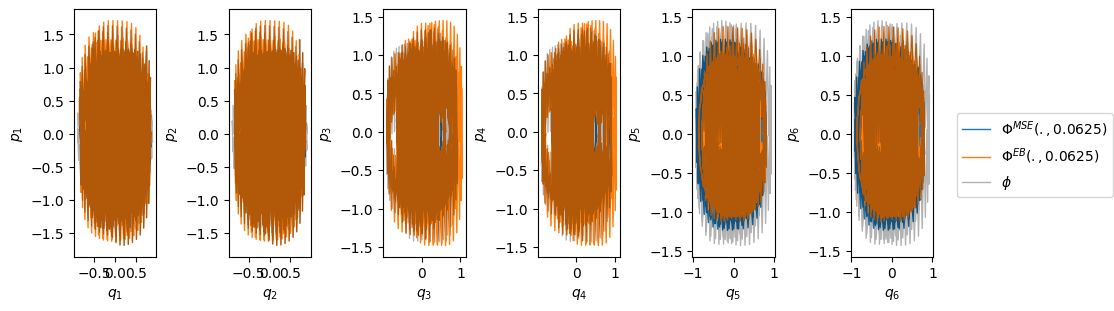

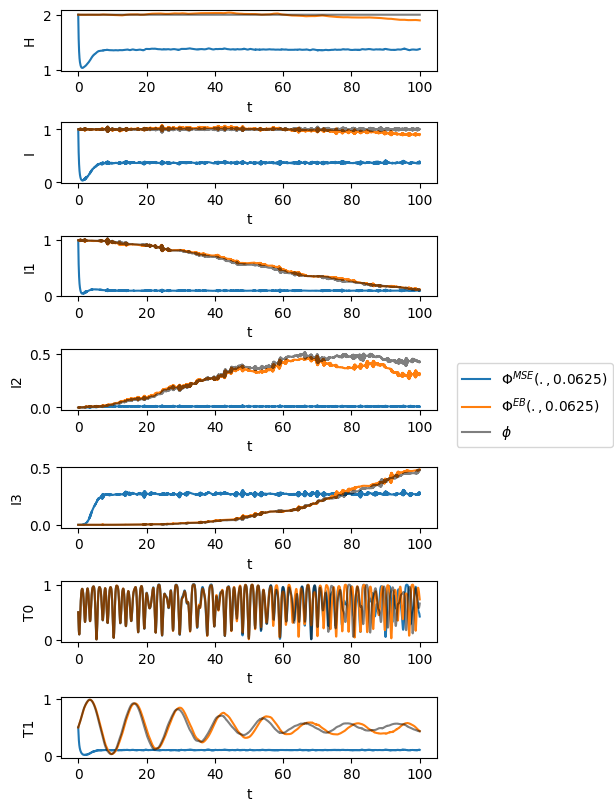

After alignment: 
	traj = FPUTrajectory(t_range=[0.0, 100.0], dt=0.0625, u0=[0.         1.41421356 0.         0.         0.         0.
 0.69296465 0.72124892 0.         0.         0.         0.        ], states=States(problem=FPU(omega=50.0), shape=(1601, 12)))
	ref_traj = FPUTrajectory(t_range=[0.0, 100.0], dt=0.0625, u0=[0.         1.41421356 0.         0.         0.         0.
 0.69296465 0.72124892 0.         0.         0.         0.        ], states=States(problem=FPU(omega=50.0), shape=(1601, 12)))
$\Phi^{MSE}(.,0.0625)$ n=1 abs_traj_err = 0.10838297769740717
$\Phi^{MSE}(.,0.0625)$ n=1600 abs_traj_err = 2.303122502573223
$\Phi^{MSE}(.,0.0625)$ n=1 abs_H_err = 0.2458855380724776
$\Phi^{MSE}(.,0.0625)$ n=1600 abs_H_err = 0.6204269048451132
$\Phi^{MSE}(.,0.0625)$ n=1 abs_traj_err_y0 = 0.00016258911047702598
$\Phi^{MSE}(.,0.0625)$ n=1600 abs_traj_err_y0 = 1.562666403244938
$\Phi^{MSE}(.,0.0625)$ n=1 abs_traj_err_x0 = 0.00013882493410332769
$\Phi^{MSE}(.,0.0625)$ n=1600 abs_traj_err_x

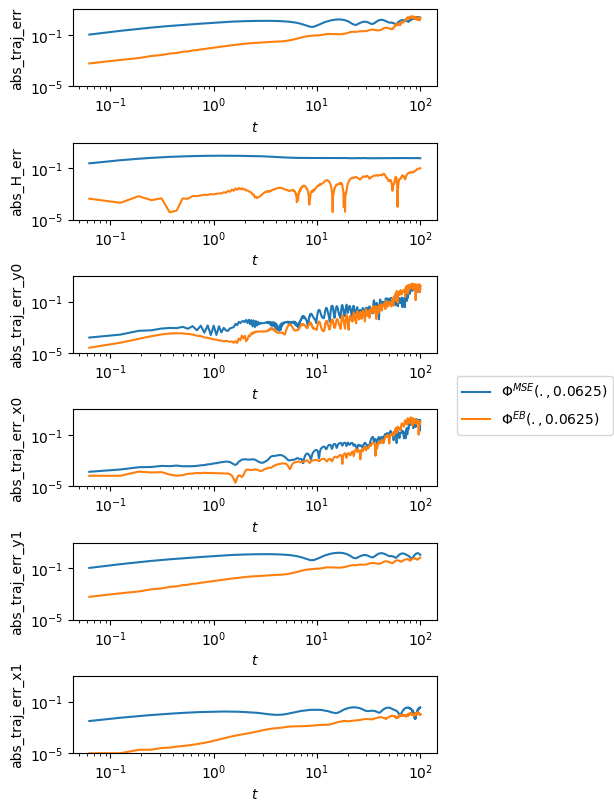

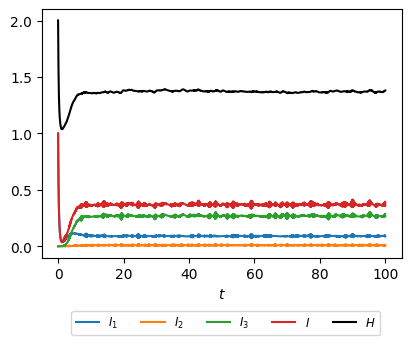

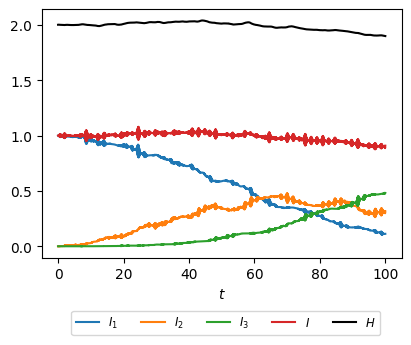

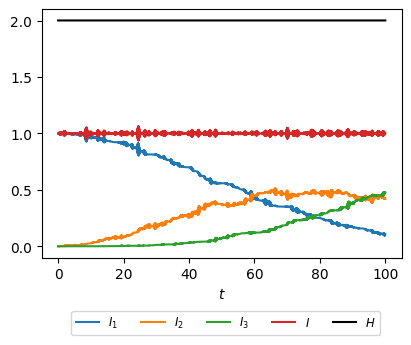

In [12]:
# --- Plot ---

# Set model labels for plotting
# model_labels_for_plotting = ["$\Phi_{S0F0}(.,0.0625)$", "$\Phi_{S2F0}(.,0.0625)$"] 
# model_labels_for_plotting = ["$\Phi_{T_0=1}^{S=1}$", "$\Phi_{T_0=1}^{S=3}$", "$\Phi_{T_0=1}^{S=5}$"] 
# model_labels_for_plotting = ["$\Phi_{T_0=1}^{MSE}$", "$\Phi_{T_0=1}^{EB}$"] 
model_labels_for_plotting = ["$\Phi^{MSE}(.,0.0625)$", "$\Phi^{EB}(.,0.0625)$"] 
# model_labels_for_plotting = ["$\Phi^{[0,0.125]}(.,0.125)$", "$\Phi^{[0,0.25]}(.,0.125)$", "$\Phi^{[0,0.5]}(.,0.125)$", "$\Phi^{[0,1]}(.,0.125)$"] 
# model_labels_for_plotting = ["$\Phi(.,0.125)$", "$\Phi_{T_0=1}$"] 
# model_labels_for_plotting = ["$\Phi_{T_0=1}$"] 

# If you want to use the original model_labels, uncomment the following line:
# model_labels_for_plotting = model_labels

# Build trajectory lists for plotting
all_trajs, all_labels, all_colors = build_recursive_trajectory_list(
    pred_trajs, model_labels_for_plotting, ref_traj, dt_list, T_end
)

# Plot phase space
viz.plot_phase_space(
    all_trajs, 
    legend_labels=all_labels, 
    show_legend=True,
    figsize=(11, 3)
)

# Plot trajectory history
viz.plot_history(
    all_trajs,
    func_dict={
        'H': lambda u: processor.compute_hamiltonian(u),
        'I': lambda u: processor.compute_stiff_spring_energies(u)[:, 3],
        'I1': lambda u: processor.compute_stiff_spring_energies(u)[:, 0],
        'I2': lambda u: processor.compute_stiff_spring_energies(u)[:, 1],
        'I3': lambda u: processor.compute_stiff_spring_energies(u)[:, 2],
        'T0': processor.compute_T0,
        'T1': processor.compute_T1,
    },
    xlabel='t', legend_labels=all_labels, colors=all_colors,
    show_legend=True, figsize=(6, 8),
)

# Plot errors against reference
error_trajs, error_labels, error_colors = build_recursive_trajectory_list(
    pred_trajs, model_labels_for_plotting, None, dt_list, T_end
)
error_linestyles = ["-"] * len(model_labels)

viz.plot_errors(
    error_trajs, ref_traj, 
    error_names=["abs_traj_err", "abs_H_err", "abs_traj_err_y0", "abs_traj_err_x0", "abs_traj_err_y1", "abs_traj_err_x1"], 
    legend_labels=error_labels, show_legend=True, 
    linestyles=error_linestyles, colors=error_colors,
    ylims=[(1e-5, 1e1)] * 6, log_xscale=True, figsize=(6, 8),
)

# Plot stiff spring energies
for traj in all_trajs:
    viz.plot_stiff_spring_energies(
        traj
    )

In [13]:
viz.plot_history_matlab(
    all_trajs,
    func_dict={
        '$H$': lambda u: processor.compute_hamiltonian(u),
        '$I$': lambda u: processor.compute_stiff_spring_energies(u)[:, 3],
        '$I_1$': lambda u: processor.compute_stiff_spring_energies(u)[:, 0],
        '$I_2$': lambda u: processor.compute_stiff_spring_energies(u)[:, 1],
        '$I_3$': lambda u: processor.compute_stiff_spring_energies(u)[:, 2],
        '$K_s$': processor.compute_T0,
        '$K_f$': processor.compute_T1,
    },
    xlabel='$t$', legend_labels=all_labels, colors=all_colors,
    ylims=[(1.5, 2.5), (0.5, 1.5)] + [(-0.1, 1.1)] * 5,
    show_legend=True, 
    figsize=(3, 7),
    save_path='./out/fpu/omega=50/energybased/energybased_residualloss_longtime_energies.pdf'
)

Current figure size: 3.0" x 7.0"
New figure size: 3.0" x 7.0"
Saved figure as: ./out/fpu/omega=50/energybased/energybased_residualloss_longtime_energies.pdf and ./out/fpu/omega=50/energybased/energybased_residualloss_longtime_energies.fig


In [45]:
viz.plot_errors_matlab(
    error_trajs, ref_traj, 
    error_names=["abs_traj_err", "abs_H_err", "abs_traj_err_y0", "abs_traj_err_x0", "abs_traj_err_y1", "abs_traj_err_x1"], 
    legend_labels=error_labels, show_legend=True, 
    linestyles=error_linestyles, colors=error_colors,
    ylims=[(1e-5, 1e1)] * 6, log_xscale=True, 
    figsize=(3, 7),
    save_path='./out/fpu/omega=50/best/best_longtime_errors.pdf'
)

After alignment: 
	traj = FPUTrajectory(t_range=[0.0, 200.0], dt=0.0625, u0=[0.         1.41421356 0.         0.         0.         0.
 0.69296465 0.72124892 0.         0.         0.         0.        ], states=States(problem=FPU(omega=50.0), shape=(3201, 12)))
	ref_traj = FPUTrajectory(t_range=[0.0, 200.0], dt=0.0625, u0=[0.         1.41421356 0.         0.         0.         0.
 0.69296465 0.72124892 0.         0.         0.         0.        ], states=States(problem=FPU(omega=50.0), shape=(3201, 12)))
After alignment: 
	traj = FPUTrajectory(t_range=[0.0, 200.0], dt=1.0, u0=[0.         1.41421356 0.         0.         0.         0.
 0.69296465 0.72124892 0.         0.         0.         0.        ], states=States(problem=FPU(omega=50.0), shape=(201, 12)))
	ref_traj = FPUTrajectory(t_range=[0.0, 200.0], dt=1.0, u0=[0.         1.41421356 0.         0.         0.         0.
 0.69296465 0.72124892 0.         0.         0.         0.        ], states=States(problem=FPU(omega=50.0), shape=

In [53]:
viz.plot_stiff_spring_energies_matlab(
    pred_trajs[0].select_with_interval(1.0).select_between(0, 500),
    figsize=(4, 3.5),
    ylim=(-0.2, 2.2),
    save_path="./out/fpu/omega=300/best/t_1_stiff_spring_energies_PhiT0.pdf"
)

Current figure size: 4.0" x 3.5"
New figure size: 4.0" x 3.5"
Saved figure as: ./out/fpu/omega=300/best/t_1_stiff_spring_energies_PhiT0.pdf and ./out/fpu/omega=300/best/t_1_stiff_spring_energies_PhiT0.fig
